<a href="https://colab.research.google.com/github/RooneyTP/Scientific-Computing/blob/main/AOLScicomp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### No 1. Exponential Regression

Menggunakan regresi karena kita mencari fungsi yang paling bisa menjelaskan trend dari data tersebut, naik atau turun. Sedangkan interpolation itu dipakai untuk mencari fungsi yang melewati semua titik data dengan tepat. Menurut saya itu tidak mungkin terjadi di dalam soal ini karena titik data nya agak acak tapi mempunyai trend yang jelas yaitu naik

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
plt.style.use('seaborn-v0_8-poster')

In [ ]:
df = pd.read_excel('https://docs.google.com/spreadsheets/d/1yqw50YB6W2xczNkLP-LEZ7zFG-rSP0Bl/export?format=xlsx', header=None)

Menggunakan Exponential Regression: y = a.e^(bx)
diubah menjadi ln(y) = ln(a) + bx -> ini mirip dengan persamaan least square regression yaitu Y = mx + c

jadi dapat diambil hubungan ln(y) = Y, m = b, dan ln(a) = c
maka dari itu, dapat digunakan metode least square regression untuk mencari formula dari exponential regression

In [ ]:
y = pd.to_numeric(df.iloc[1, :], errors='coerce').dropna().values.reshape(-1, 1)

In [ ]:
x = np.arange(1, len(y)+1)

In [ ]:
lny = np.log(y)

In [ ]:
m = np.vstack([x, np.ones(len(x))]).T

In [ ]:
alpha = np.dot(np.dot(np.linalg.inv(np.dot(m.T, m)), m.T), lny)
print(alpha.flatten())
print("a = ", np.exp(alpha[1]).item())
print("b = ", alpha[0].item())
a = np.exp(alpha[1])
b = alpha[0]

[0.01534032 7.56890286]
a =  1937.0139340177084
b =  0.015340315939818517


Menghitung koefisien determinasi dan koefisien korelasi untuk menghitung akurasi grafik saat menggunakan exponential regression agar trend nya akurat dengan data tas ini.

In [ ]:
Y = a*(np.exp(b*x))
yMean = np.mean(Y)

In [ ]:
SST = np.sum((y - Y)**2)
SSR = np.sum((y - yMean)**2)

In [ ]:
R = 1 - (SSR/SST)
r = np.sqrt(R)

In [ ]:
print(f"Koefisien Determinasi = {R:.3f}")
print(f"Koefisien Korelasi = {r:.3f}")

Koefisien Determinasi = 0.997
Koefisien Korelasi = 0.998


Dapat dilihat dari Koefisien Determinasi dan Koefisien Korelasi yang mendekati 1, tepatnya R = 0.997 dan r = 0.998 hal tersebut berarti trend dari fungsi yang didapat dari exponential regression ini hampir sesuai yaitu 99,7% akurat dan cocok dalam menangkap tren kenaikan produksi tas EGIER

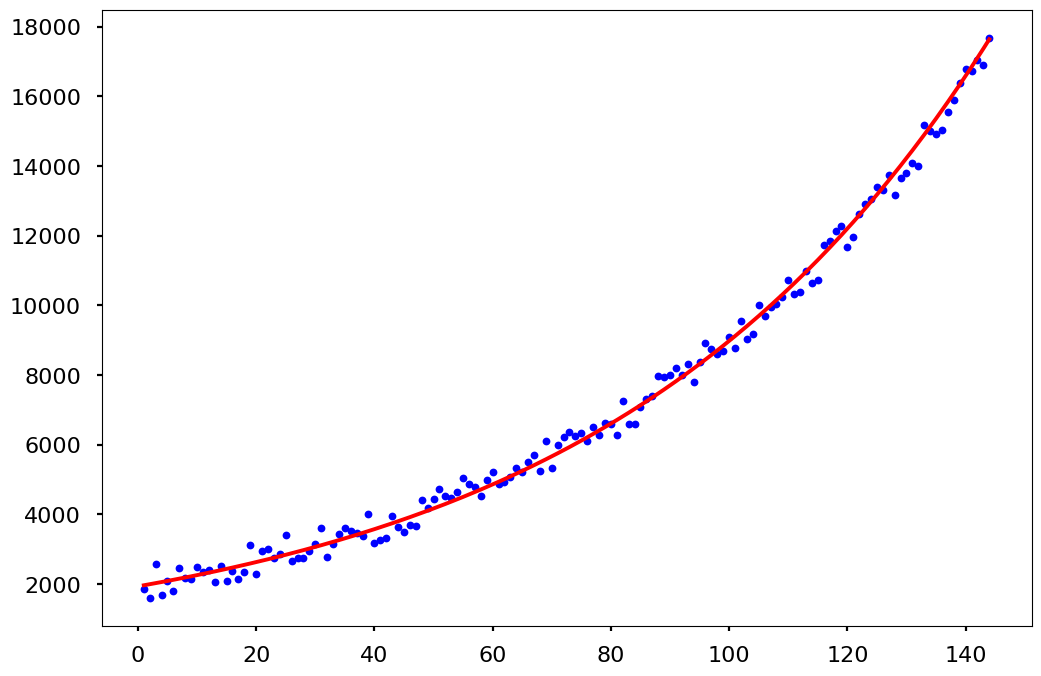

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(x, y, 'b.')
plt.plot(x, a*(np.exp(b*x)), 'r')
plt.show()

### No 2. Taylor Series

In [ ]:
aScalar = a[0]
bScalar = b[0]

In [ ]:
def faktorial(n):
  if n == 0 and n == 1:
    return 1
  hasil = 1
  for i in range(1, n+1):
    hasil *= i
  return hasil

kalau persamaan y = a.e^(bx) dibuat ke dalam taylor series

y' = ab.e^(bx)

y'' = ab^2.e^(bx)

...

turunan ke n dari y = ab^n.e^(bx)

jadi taylor series ketika x = 0, atau maclaurin series nya menjadi:

f(0)+f'(0)x+f"(0)x^2/2+f"'(0)x^3/3!+f""(0)x^4/4!+f""'(0)x^5/5!+O((bx)^6)

In [ ]:
def taylor(a, b, x, orde):
  hasilTaylor = 0
  for i in range(orde+1):
    sukuKei = (a*(b*x)**i)/faktorial(i)
    hasilTaylor += sukuKei
  return hasilTaylor

Membuat yTaylorOrde2 dan yTaylorOrde5 dengan x=[1, 144] sebagai perbandingan dengan fungsi aslinya, ambil angka acak yaitu 120 sebagai xTest nya dan yTest sebagai fungsi aslinya yaitu y ketika x=120

In [ ]:
yTaylorOrde2 = [taylor(aScalar, bScalar, val, 2) for val in x]
yTaylorOrde5 = [taylor(aScalar, bScalar, val, 5) for val in x]

In [ ]:
xTest = 120

In [ ]:
yTest = aScalar * np.exp(bScalar*xTest)

In [ ]:
taylor5 = taylor(aScalar, bScalar, xTest, 5)

In [ ]:
truncationError = abs(yTest - taylor5)

In [ ]:
print(f"Analisis truncation error dengan x = {xTest}")
print(f"Nilai asli y = {yTest:.3f}")
print(f"Nilai taylor orde ke-5 = {taylor5:.3f}")
print(f"Truncation error = {truncationError:.3f}")

Analisis truncation error dengan x = 120
Nilai asli y = 12206.706
Nilai taylor orde ke-5 = 12066.573
Truncation error = 140.134


Bisa dilihat untuk nilai y ketika x = 120 adalah 12206.706, nilai y ini sudah dekat dengan nilai taylor pada orde ke-5 karena penambahan suku derajat lebih tinggi memperkecil sisa error/truncationError menjadi lebih kecil. Jadi kita dapat menggunakan [y = taylor5 + truncationError] sehingga untuk mendapatkan [truncationError = |y - taylor5|]. truncationError itu O(h^6) dengan h = bx

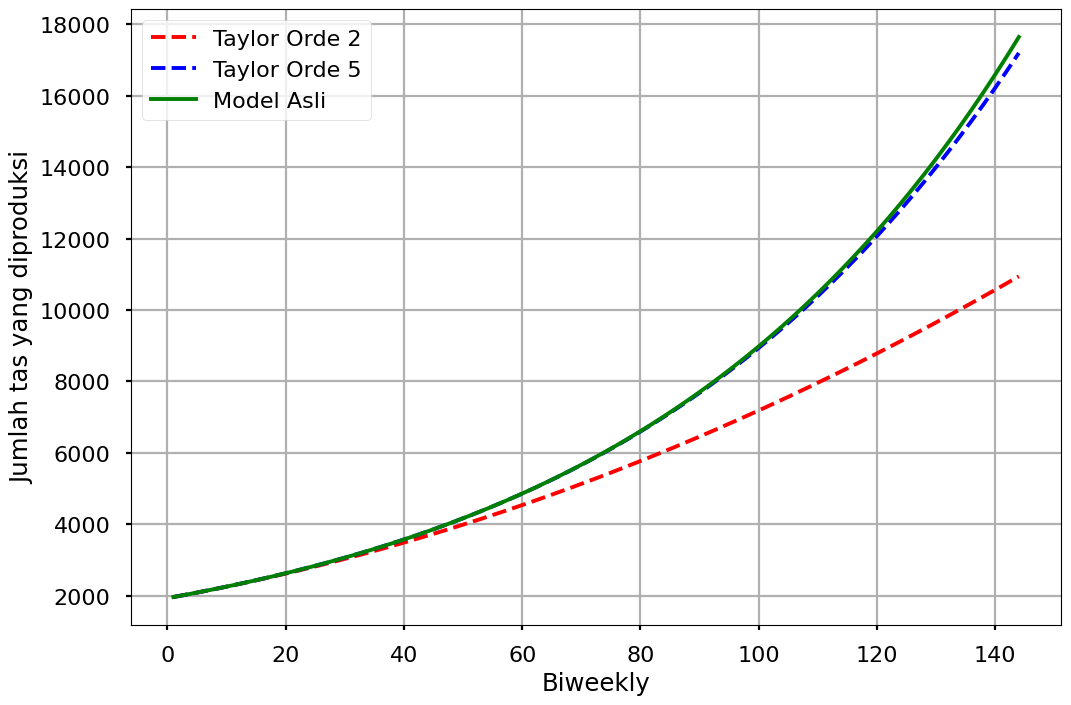

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(x, yTaylorOrde2, '--r', label='Taylor Orde 2')
plt.plot(x, yTaylorOrde5, '--b', label='Taylor Orde 5')
plt.plot(x, aScalar*np.exp(bScalar*x), 'g', label='Model Asli')
plt.xlabel('Biweekly')
plt.ylabel('Jumlah tas yang diproduksi')
plt.legend()
plt.grid(True)
plt.show()

### No 3. Root Finding using Newton-Raphson Method

With f(x) = 25000 -> f(x) - 25000 = 0

atau berarti a.e^(bx) = 25000 -> a.e^(bx) - 25000 = 0

maka F(x) adalah a.e^(bx) - 25000

menggunakan metode newtonRaphson karena metode ini lebih cepat daripada bisection method. karena fungsi kita mempunyai pola yang mudah saat kita menggunakan metode ini yaitu:

y = a.e^(bx) - 25000 dan
y' = ab.e^(bx)
dapat dilihat dari fungsi turunannya, nilai analitiknya sangat mudah didapat, sehingga komputasi iterasi pembagian y/y' berjalan dengan efisien

jadi metode ini sangat cocok dengan fungsi kita saat ini

In [ ]:
Froot = lambda x: aScalar*np.exp(bScalar*x) - 25000

In [ ]:
froot = lambda x: aScalar*bScalar*np.exp(bScalar*x)

In [ ]:
def newtonRaphson(F, f, xTebakan, epsilon = 0.0001, iter=100):
  valLama = xTebakan
  for i in range(iter):
    nilaiFroot = F(valLama)
    nilaifroot = f(valLama)
    if nilaifroot == 0:
      return 0

    valBaru = valLama - (nilaiFroot/nilaifroot)
    error = abs(valBaru - valLama)

    print(f"Iterasi {i+1:2d}, Periode = {valBaru:.3f}, Error = {error:.3f}")

    if error < epsilon:
      return valBaru

    valLama = valBaru

  return None

In [ ]:
tebakan = 100
akarPeriode = newtonRaphson(Froot, froot, tebakan)

Iterasi  1, Periode = 216.260, Error = 116.260
Iterasi  2, Periode = 181.565, Error = 34.695
Iterasi  3, Periode = 168.299, Error = 13.266
Iterasi  4, Periode = 166.751, Error = 1.548
Iterasi  5, Periode = 166.732, Error = 0.019
Iterasi  6, Periode = 166.732, Error = 0.000


Pada iterasi 6 Errornya sudah kurang dari 0.001 atau 10^(-3), jadi kita memakai hasil jawaban pada iterasi ke-6 dengan memakai tebakan x nya itu 100

In [ ]:
if akarPeriode is not None:
  print("Kesimpulan: ")
  print(f"Kapasitas 25.000 tas terlampaui pada periode biweekly ke-{akarPeriode:.3f}")

  periodeBangun = int(akarPeriode) - 26
  print(f"EGIER harus membangun gudang baru paling lambat pada periode ke-{periodeBangun}")

Kesimpulan: 
Kapasitas 25.000 tas terlampaui pada periode biweekly ke-166.732
EGIER harus membangun gudang baru paling lambat pada periode ke-140


Dinyatakan kalau pembangunan warehouse dimulai 13 bulan sebelum kapasitas 25.000 tas nya terlampaui. Dengan anggapan 1 bulan itu 4 minggu atau 2 biweekly. Jadi periode awal dikurang 13*2, atau persamaanya adalah

periodeBangun = akarPeriode - 26

dengan akarPeriode adalah periode dimana kapasitas 25.000 itu terpenuhi

### No 4.

No 4a. Numerical Differentiation

ada 144 periode biweekly = 72 bulan, dengan anggapan 1 bulan = 4 minggu

2018 = 1-12

2019 = 13-24

2020 = 25-36

2021 = 37-48

Menggunakan central difference agar lebih akurat, karena menghitung selisih titik setelah dan sebelumnya, sedangkan kalau forward menghitung selisih titik setelahnya dan backward menghitung selisih titik sebelumnya. Terus karena ini data dari masa lalu jadi bisa menggunakan central difference, kalau data ini terbaru maka menggunakan backward difference

In [ ]:
dataBulanan = []
dataBiweekly = y

In [ ]:
for i in range(0, len(dataBiweekly), 2):
  produksiSebulan = dataBiweekly[i] + dataBiweekly[i+1]
  dataBulanan.append(produksiSebulan)

print(f"Total data bulanan terkumpul adalah sebanyak {len(dataBulanan)} bulan")

Total data bulanan terkumpul adalah sebanyak 72 bulan


Menghitung Monthly Rate of Change untuk tahun 2020 dan 2021

In [ ]:
rateOfChange = {}

In [ ]:
for i in range(24, 48):
  bulanAsli = i+1
  rate = (dataBulanan[i+1].item() - dataBulanan[i-1].item()) / 2
  rateOfChange[bulanAsli] = rate
  print(f"Bulan ke-{bulanAsli:2d}, Rate of Change: {rate:.3f} tas/bulan")

Bulan ke-25, Rate of Change: 589.000 tas/bulan
Bulan ke-26, Rate of Change: 245.500 tas/bulan
Bulan ke-27, Rate of Change: 327.500 tas/bulan
Bulan ke-28, Rate of Change: 102.000 tas/bulan
Bulan ke-29, Rate of Change: 137.000 tas/bulan
Bulan ke-30, Rate of Change: 240.000 tas/bulan
Bulan ke-31, Rate of Change: 116.000 tas/bulan
Bulan ke-32, Rate of Change: 469.500 tas/bulan
Bulan ke-33, Rate of Change: 278.000 tas/bulan
Bulan ke-34, Rate of Change: 346.000 tas/bulan
Bulan ke-35, Rate of Change: 624.500 tas/bulan
Bulan ke-36, Rate of Change: 593.500 tas/bulan
Bulan ke-37, Rate of Change: 120.000 tas/bulan
Bulan ke-38, Rate of Change: 72.000 tas/bulan
Bulan ke-39, Rate of Change: 382.500 tas/bulan
Bulan ke-40, Rate of Change: 371.000 tas/bulan
Bulan ke-41, Rate of Change: -25.000 tas/bulan
Bulan ke-42, Rate of Change: 450.500 tas/bulan
Bulan ke-43, Rate of Change: 1103.500 tas/bulan
Bulan ke-44, Rate of Change: 776.500 tas/bulan
Bulan ke-45, Rate of Change: 409.000 tas/bulan
Bulan ke-46, 

In [ ]:
bulanNaik = max(rateOfChange, key=rateOfChange.get)
nilaiNaik = rateOfChange[bulanNaik]

In [ ]:
bulanTurun = min(rateOfChange, key=rateOfChange.get)
nilaiTurun = rateOfChange[bulanTurun]

In [ ]:
print(f"Steepest Increase terjadi pada Bulan ke-{bulanNaik} dengan nilai naik sebesar {nilaiNaik:.3f} tas/bulan")
print(f"Steepest Decrease terjadi pada Bulan ke-{bulanTurun} dengan nilai turun sebesar {nilaiTurun:.3f} tas/bulan")

Steepest Increase terjadi pada Bulan ke-43 dengan nilai naik sebesar 1103.500 tas/bulan
Steepest Decrease terjadi pada Bulan ke-41 dengan nilai turun sebesar -25.000 tas/bulan


No 4b.

totalInterval = totalTitik -1

totalInterval = 144-1 = 143 = 140 + 3
karena ganjil, menggunakan metode simpson's rule 3/8 dan 1/3 untuk menghitung total produksi selama Januari 2018 sampai Desember 2023 adalah cara terbaik karena keduanya mempunyai akurasi tinggi dengan truncation errornya O(h^4)
140 interval menggunakan simpson's 1/3 dan 3 lagi menggunakan simpson's 3/8

In [ ]:
totalRaw = np.sum(dataBiweekly)
print(f"Total produksi = {totalRaw} tas")

Total produksi = 1030745 tas


In [ ]:
h = 1
batas1per3 = 140
integral1per3 = 0

In [ ]:
for i in range(0, batas1per3, 2):
  L = h/3* (dataBiweekly[i] + 4*dataBiweekly[i+1] + dataBiweekly[i+2])
  integral1per3 += L

In [ ]:
print(integral1per3.item())

967700.333333333


In [ ]:
integral3per8 = 3*h/8*(dataBiweekly[140] + 3*dataBiweekly[141] + 3*dataBiweekly[142] + dataBiweekly[143])
print(integral3per8.item())

51072.0


In [ ]:
totalIntegral = integral1per3.item() + integral3per8.item()
errorJumlahProduksi = abs(totalRaw - totalIntegral)

In [ ]:
print(f"Total produksi asli = {totalRaw:.3f} tas")
print(f"Total produksi lewat integrasi = {totalIntegral:.3f} tas")
print(f"Selisih akurasi error = {errorJumlahProduksi:.3f} tas")

Total produksi asli = 1030745.000 tas
Total produksi lewat integrasi = 1018772.333 tas
Selisih akurasi error = 11972.667 tas
